In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
IMG_DIR = "/content/drive/MyDrive/archive (8)/images"

df = pd.read_csv(CSV_PATH, sep=None, engine='python')
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(8080, 18)


,Sample_ID,Data_Type,Condition,Damage_Type,Vent_Holes,Fiber_Volume_Fraction,Void_Content,Fiber_Orientation_Degree,LBP_Feature_1,LBP_Feature_2,Texture_Contrast,Average_Temperature,Temperature_Variance,Defect_Density,Crack_Length_mm,Fracture_Toughness,Tensile_Strength,Structural_Integrity_Class
0,1,Thermograph,Mixed,NaN,4,0.566,0.058,3.28,0.984,0.389,0.313,26.60,1.79,0.128,2.310,31.30,372.62,Medium
1,2,C-scan (BVID with Holes),Damaged,BVID,5,0.601,0.050,18.99,0.420,0.538,0.627,74.07,6.47,0.154,2.983,49.43,413.52,Medium
2,3,C-scan (Pristine with Holes),Pristine,NaN,3,0.693,0.069,63.80,0.926,0.484,0.358,58.57,12.74,0.035,0.739,34.65,497.68,Medium
3,4,C-scan (BVID with Holes),Damaged,BVID,6,0.501,0.047,52.88,0.993,0.928,0.265,32.47,1.51,0.130,2.673,31.30,505.09,Medium
4,5,C-scan (Pristine with Holes),Pristine,NaN,2,0.502,0.010,51.37,0.378,0.352,0.699,29.69,6.09,0.018,0.413,59.72,515.48,High


In [7]:
import os, cv2, torch, numpy as np, pandas as pd
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
torch.backends.cudnn.benchmark = True

# =========================
# MOVE IMAGES TO LOCAL (FAST)
# =========================
if not os.path.exists("/content/images"):
    !cp -r "/content/drive/MyDrive/archive (8)/images" /content/images

# =========================
# PATHS
# =========================
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
IMG_DIR = "/content/images"

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

# =========================
# CLEAN FIRST (VERY IMPORTANT)
# =========================
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].astype(str).str.strip()
mapping = {'Low':0, 'Medium':1, 'High':2}
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].map(mapping)

df = df.dropna().reset_index(drop=True)

# =========================
# BUILD IMAGE POOL
# =========================
img_dict = {}

for root, dirs, files in os.walk(IMG_DIR):
    if len(files) == 0:
        continue

    folder = os.path.basename(root)

    valid = [
        os.path.join(root, f)
        for f in files
        if f.lower().endswith(('.png','.jpg','.jpeg'))
    ]

    img_dict[folder] = valid

print("Image distribution:")
for k,v in img_dict.items():
    print(k, len(v))

# =========================
# IMAGE ASSIGNMENT
# =========================
def assign_image(row):
    dtype = row['Data_Type']

    if dtype in img_dict:
        return np.random.choice(img_dict[dtype])

    if 'Thermo' in dtype:
        return np.random.choice(img_dict.get('Thermograph', []))

    if 'Pristine' in dtype:
        return np.random.choice(img_dict.get('C-scan (Pristine with Holes)', []))

    if 'BVID' in dtype or 'Damage' in dtype:
        return np.random.choice(img_dict.get('C-scan (BVID with Holes)', []))

    return None

df['img_path'] = df.apply(assign_image, axis=1)
df = df[df['img_path'].notnull()].reset_index(drop=True)

print("After image assignment:", df.shape)

# =========================
# FEATURES
# =========================
num_cols = [
 'Vent_Holes','Fiber_Volume_Fraction','Void_Content','Fiber_Orientation_Degree',
 'LBP_Feature_1','LBP_Feature_2','Texture_Contrast',
 'Average_Temperature','Temperature_Variance','Defect_Density','Crack_Length_mm'
]

cat_cols = ['Data_Type','Condition','Damage_Type']

# =========================
# ENCODING
# =========================
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])

scaler_X = StandardScaler()
X_num = scaler_X.fit_transform(df[num_cols])

X_tab = np.hstack([X_num, cat_encoded])

y_cls = df['Structural_Integrity_Class'].values
y_reg = df[['Tensile_Strength','Fracture_Toughness']].values

scaler_y = StandardScaler()
y_reg = scaler_y.fit_transform(y_reg)

# =========================
# FINAL CHECK (MANDATORY)
# =========================
print("Final check:")
print("X_tab:", X_tab.shape)
print("y_cls:", len(y_cls))
print("paths:", len(df['img_path']))

# =========================
# SPLIT BY IMAGE (NO LEAKAGE)
# =========================
unique_imgs = df['img_path'].unique()

train_imgs, test_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=42)

train_df = df[df['img_path'].isin(train_imgs)].reset_index(drop=True)
test_df  = df[df['img_path'].isin(test_imgs)].reset_index(drop=True)

# rebuild arrays
Xtr_tab = X_tab[train_df.index]
Xte_tab = X_tab[test_df.index]

ytr_cls = y_cls[train_df.index]
yte_cls = y_cls[test_df.index]

ytr_reg = y_reg[train_df.index]
yte_reg = y_reg[test_df.index]

p_tr = train_df['img_path'].values
p_te = test_df['img_path'].values

# =========================
# DATASET
# =========================
class CFRPDataset(Dataset):
    def __init__(self, X_tab, paths, y_cls, y_reg):
        self.X_tab = X_tab
        self.paths = paths
        self.y_cls = y_cls
        self.y_reg = y_reg

    def __len__(self):
        return len(self.X_tab)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])

        if img is None:
            img = np.zeros((128,128,3))
        else:
            img = cv2.resize(img, (128,128))

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        return (
            torch.tensor(self.X_tab[idx]).float(),
            torch.tensor(img).float(),
            torch.tensor(self.y_cls[idx]).long(),
            torch.tensor(self.y_reg[idx]).float()
        )

train_ds = CFRPDataset(Xtr_tab, p_tr, ytr_cls, ytr_reg)
test_ds  = CFRPDataset(Xte_tab, p_te, yte_cls, yte_reg)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32)

# =========================
# MODEL (PRETRAINED)
# =========================
class MultiModalNet(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()

        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Linear(512, 128)

        # Freeze CNN
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.tab = nn.Sequential(
            nn.Linear(tab_dim,128),
            nn.ReLU(),
            nn.Linear(128,64)
        )

        self.fc = nn.Sequential(
            nn.Linear(128+64,128),
            nn.ReLU()
        )

        self.cls = nn.Linear(128,3)
        self.reg = nn.Linear(128,2)

    def forward(self, tab, img):
        img_feat = self.cnn(img)
        tab_feat = self.tab(tab)

        x = torch.cat([img_feat, tab_feat], dim=1)
        x = self.fc(x)

        return self.cls(x), self.reg(x)

# =========================
# TRAINING
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalNet(X_tab.shape[1]).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
ce = nn.CrossEntropyLoss()
mse = nn.MSELoss()

for epoch in range(15):
    model.train()
    total_loss = 0

    for tab, img, yc, yr in train_loader:
        tab, img = tab.to(DEVICE), img.to(DEVICE)
        yc, yr = yc.to(DEVICE), yr.to(DEVICE)

        out_cls, out_reg = model(tab, img)

        loss = ce(out_cls, yc) + 0.3 * mse(out_reg, yr)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")

# =========================
# EVALUATION
# =========================
model.eval()

pred_cls, true_cls = [], []
pred_reg, true_reg = [], []

with torch.no_grad():
    for tab, img, yc, yr in test_loader:
        tab, img = tab.to(DEVICE), img.to(DEVICE)

        out_cls, out_reg = model(tab, img)

        pred_cls.extend(torch.argmax(out_cls,1).cpu().numpy())
        true_cls.extend(yc.numpy())

        pred_reg.extend(out_reg.cpu().numpy())
        true_reg.extend(yr.numpy())

print("Classification Accuracy:", accuracy_score(true_cls, pred_cls))
print("Regression R2:", r2_score(true_reg, pred_reg))

Image distribution:
Thermograph 15
C-scan (Pristine with Holes) 9
C-scan (BVID with Holes) 9
After image assignment: (4080, 19)
Final check:
X_tab: (4080, 17)
y_cls: 4080
paths: 4080
Epoch 0 Loss 101.8304
Epoch 1 Loss 94.6052
Epoch 2 Loss 94.2763
Epoch 3 Loss 92.8116
Epoch 4 Loss 92.3868
Epoch 5 Loss 92.1869
Epoch 6 Loss 91.7735
Epoch 7 Loss 91.6749
Epoch 8 Loss 91.2825
Epoch 9 Loss 90.6207
Epoch 10 Loss 89.6294
Epoch 11 Loss 89.5136
Epoch 12 Loss 88.1241
Epoch 13 Loss 87.8563
Epoch 14 Loss 86.3575
Classification Accuracy: 0.7205567451820128
Regression R2: 0.009848819699500522


In [8]:
print(df[['Tensile_Strength','Fracture_Toughness'] + num_cols].corr())

                          Tensile_Strength  Fracture_Toughness  Vent_Holes  \
Tensile_Strength                  1.000000            0.033145   -0.002054   
Fracture_Toughness                0.033145            1.000000    0.013041   
Vent_Holes                       -0.002054            0.013041    1.000000   
Fiber_Volume_Fraction             0.002882           -0.001952   -0.000335   
Void_Content                      0.001272            0.015260   -0.015995   
Fiber_Orientation_Degree         -0.032849           -0.017034   -0.003600   
LBP_Feature_1                    -0.002695           -0.005900    0.009870   
LBP_Feature_2                     0.020933           -0.000355   -0.009765   
Texture_Contrast                  0.003771            0.007730   -0.014454   
Average_Temperature               0.011097            0.003947   -0.010386   
Temperature_Variance              0.017312            0.015815   -0.020786   
Defect_Density                   -0.026379            0.004847  

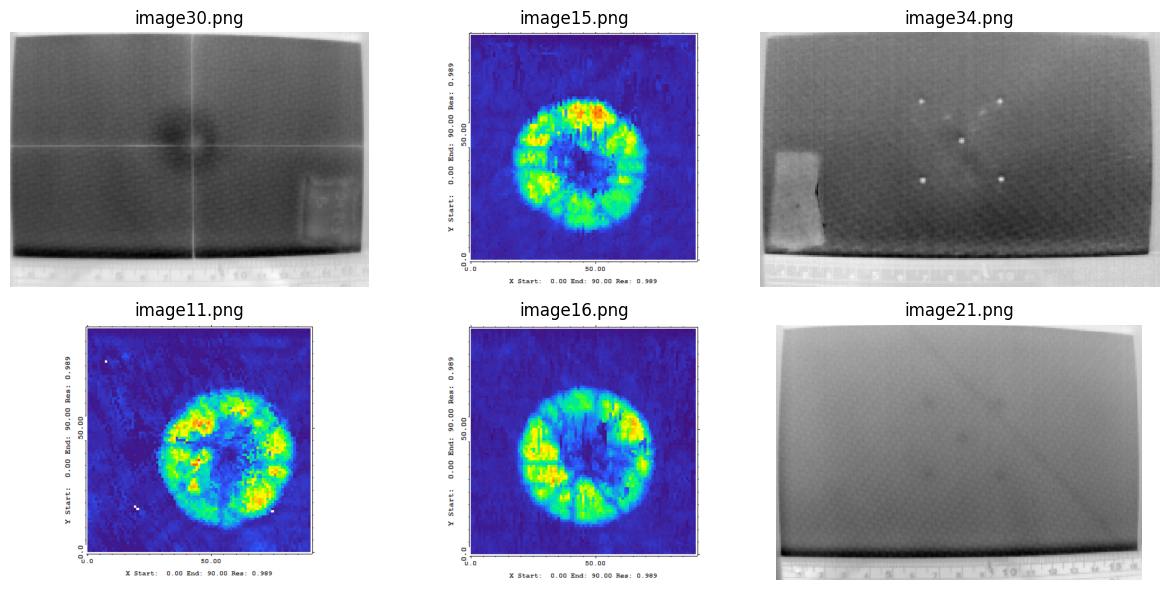

In [9]:
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(list(df['img_path']), 6)

plt.figure(figsize=(12,6))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis('off')

plt.tight_layout()
plt.show()

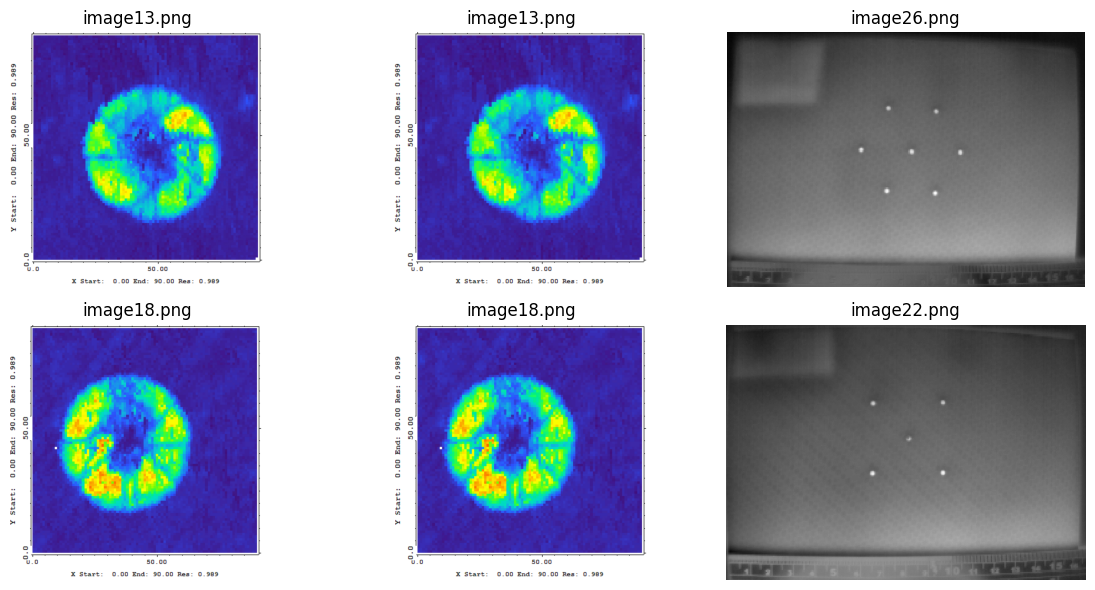

In [10]:
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(list(df['img_path']), 6)

plt.figure(figsize=(12,6))

for i, path in enumerate(sample_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
print(df[['img_mean','img_std','edge_density','Tensile_Strength']].corr())

KeyError: "['img_mean', 'img_std', 'edge_density'] not in index"

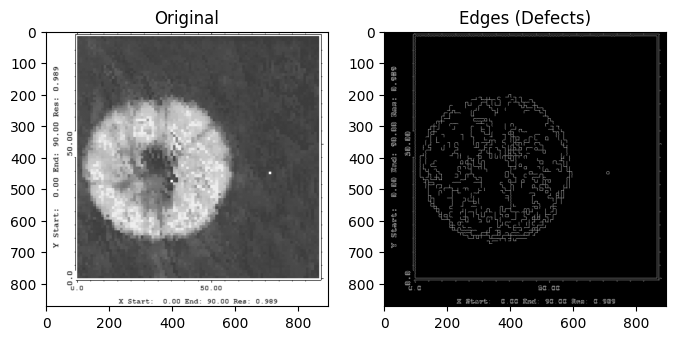

In [12]:
img = cv2.imread(df['img_path'].iloc[0], 0)
edges = cv2.Canny(img, 100, 200)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges (Defects)")

plt.show()

In [13]:
def defect_area(path):
    img = cv2.imread(path, 0)

    # threshold to isolate bright/damage regions
    _, thresh = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

    area = np.sum(thresh > 0) / thresh.size
    return area

df['defect_area_img'] = df['img_path'].apply(defect_area)

In [15]:
def edge_density(path):
    img = cv2.imread(path, 0)
    edges = cv2.Canny(img, 100, 200)
    return np.sum(edges > 0) / edges.size

df['edge_density'] = df['img_path'].apply(edge_density)

In [16]:
def center_intensity(path):
    img = cv2.imread(path, 0)
    h, w = img.shape

    center = img[h//3:2*h//3, w//3:2*w//3]
    return np.mean(center)

df['center_intensity'] = df['img_path'].apply(center_intensity)

In [17]:
print(df[['defect_area_img','edge_density','center_intensity',
          'Tensile_Strength','Fracture_Toughness']].corr())

                    defect_area_img  edge_density  center_intensity  \
defect_area_img            1.000000      0.955547          0.837448   
edge_density               0.955547      1.000000          0.877647   
center_intensity           0.837448      0.877647          1.000000   
Tensile_Strength          -0.024147     -0.024967         -0.025683   
Fracture_Toughness         0.000260      0.001057          0.004475   

                    Tensile_Strength  Fracture_Toughness  
defect_area_img            -0.024147            0.000260  
edge_density               -0.024967            0.001057  
center_intensity           -0.025683            0.004475  
Tensile_Strength            1.000000            0.033145  
Fracture_Toughness          0.033145            1.000000  


In [18]:
# =========================
# IMPORTS
# =========================
import os, cv2, torch, numpy as np, pandas as pd
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

torch.backends.cudnn.benchmark = True

# =========================
# MOVE IMAGES TO LOCAL
# =========================
if not os.path.exists("/content/images"):
    !cp -r "/content/drive/MyDrive/archive (8)/images" /content/images

# =========================
# PATHS
# =========================
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
IMG_DIR = "/content/images"

# =========================
# LOAD + CLEAN DATA
# =========================
df = pd.read_csv(CSV_PATH)

df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].astype(str).str.strip()
mapping = {'Low':0, 'Medium':1, 'High':2}
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].map(mapping)

df = df.dropna().reset_index(drop=True)

# =========================
# BUILD IMAGE POOL
# =========================
img_dict = {}

for root, dirs, files in os.walk(IMG_DIR):
    if len(files) == 0:
        continue

    folder = os.path.basename(root)
    valid = [os.path.join(root,f) for f in files if f.endswith(('.png','.jpg','.jpeg'))]
    img_dict[folder] = valid

# =========================
# IMAGE ASSIGNMENT
# =========================
def assign_image(row):
    dtype = row['Data_Type']

    if dtype in img_dict:
        return np.random.choice(img_dict[dtype])

    if 'Thermo' in dtype:
        return np.random.choice(img_dict.get('Thermograph', []))

    if 'Pristine' in dtype:
        return np.random.choice(img_dict.get('C-scan (Pristine with Holes)', []))

    if 'BVID' in dtype or 'Damage' in dtype:
        return np.random.choice(img_dict.get('C-scan (BVID with Holes)', []))

    return None

df['img_path'] = df.apply(assign_image, axis=1)
df = df[df['img_path'].notnull()].reset_index(drop=True)

print("Final dataset:", df.shape)

# =========================
# FEATURES
# =========================
num_cols = [
 'Vent_Holes','Fiber_Volume_Fraction','Void_Content','Fiber_Orientation_Degree',
 'LBP_Feature_1','LBP_Feature_2','Texture_Contrast',
 'Average_Temperature','Temperature_Variance','Defect_Density','Crack_Length_mm'
]

cat_cols = ['Data_Type','Condition','Damage_Type']

# =========================
# ENCODING
# =========================
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])

scaler_X = StandardScaler()
X_num = scaler_X.fit_transform(df[num_cols])

X_tab = np.hstack([X_num, cat_encoded])
y = df['Structural_Integrity_Class'].values

print("Tabular shape:", X_tab.shape)

# =========================
# SPLIT BY IMAGE (NO LEAKAGE)
# =========================
unique_imgs = df['img_path'].unique()

train_imgs, test_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=42)

train_df = df[df['img_path'].isin(train_imgs)].reset_index(drop=True)
test_df  = df[df['img_path'].isin(test_imgs)].reset_index(drop=True)

Xtr_tab = X_tab[train_df.index]
Xte_tab = X_tab[test_df.index]

ytr = y[train_df.index]
yte = y[test_df.index]

p_tr = train_df['img_path'].values
p_te = test_df['img_path'].values

# =========================
# DATASET
# =========================
class CFRPDataset(Dataset):
    def __init__(self, X_tab, paths, y):
        self.X_tab = X_tab
        self.paths = paths
        self.y = y

    def __len__(self):
        return len(self.X_tab)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])

        if img is None:
            img = np.zeros((128,128,3))
        else:
            img = cv2.resize(img, (128,128))

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        return (
            torch.tensor(self.X_tab[idx]).float(),
            torch.tensor(img).float(),
            torch.tensor(self.y[idx]).long()
        )

train_ds = CFRPDataset(Xtr_tab, p_tr, ytr)
test_ds  = CFRPDataset(Xte_tab, p_te, yte)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=64, num_workers=2)

# =========================
# MODEL
# =========================
class MultiModalNet(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()

        from torchvision.models import resnet18, ResNet18_Weights
        self.cnn = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Linear(512, 128)

        # Freeze CNN
        for param in self.cnn.parameters():
            param.requires_grad = False

        self.tab = nn.Sequential(
            nn.Linear(tab_dim,128),
            nn.ReLU(),
            nn.Linear(128,64)
        )

        self.fc = nn.Sequential(
            nn.Linear(128+64,128),
            nn.ReLU()
        )

        self.cls = nn.Linear(128,3)

    def forward(self, tab, img):
        img_feat = self.cnn(img)
        tab_feat = self.tab(tab)

        x = torch.cat([img_feat, tab_feat], dim=1)
        x = self.fc(x)

        return self.cls(x)

# =========================
# TRAINING
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalNet(X_tab.shape[1]).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
ce = nn.CrossEntropyLoss()

for epoch in range(15):
    model.train()
    total_loss = 0

    for tab, img, yb in train_loader:
        tab, img, yb = tab.to(DEVICE), img.to(DEVICE), yb.to(DEVICE)

        out = model(tab, img)
        loss = ce(out, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")

# =========================
# EVALUATION
# =========================
model.eval()

preds, trues = [], []

with torch.no_grad():
    for tab, img, yb in test_loader:
        tab, img = tab.to(DEVICE), img.to(DEVICE)

        out = model(tab, img)

        preds.extend(torch.argmax(out,1).cpu().numpy())
        trues.extend(yb.numpy())

print("Final Accuracy:", accuracy_score(trues, preds))

Final dataset: (4080, 19)
Tabular shape: (4080, 17)
Epoch 0 Loss 36.4833
Epoch 1 Loss 31.6754
Epoch 2 Loss 31.0814
Epoch 3 Loss 30.5438
Epoch 4 Loss 30.3123
Epoch 5 Loss 30.3897
Epoch 6 Loss 29.9350
Epoch 7 Loss 29.6290
Epoch 8 Loss 29.9513
Epoch 9 Loss 29.4978
Epoch 10 Loss 29.5093
Epoch 11 Loss 29.1564
Epoch 12 Loss 28.8052
Epoch 13 Loss 28.5150
Epoch 14 Loss 28.2233
Final Accuracy: 0.7077798861480076


Shape: (8080, 18)

Columns:
 Index(['Sample_ID', 'Data_Type', 'Condition', 'Damage_Type', 'Vent_Holes',
       'Fiber_Volume_Fraction', 'Void_Content', 'Fiber_Orientation_Degree',
       'LBP_Feature_1', 'LBP_Feature_2', 'Texture_Contrast',
       'Average_Temperature', 'Temperature_Variance', 'Defect_Density',
       'Crack_Length_mm', 'Fracture_Toughness', 'Tensile_Strength',
       'Structural_Integrity_Class'],
      dtype='object')

Missing values:
 Sample_ID                        0
Data_Type                        0
Condition                        0
Damage_Type                   4000
Vent_Holes                       0
Fiber_Volume_Fraction            0
Void_Content                     0
Fiber_Orientation_Degree         0
LBP_Feature_1                    0
LBP_Feature_2                    0
Texture_Contrast                 0
Average_Temperature              0
Temperature_Variance             0
Defect_Density                   0
Crack_Length_mm                  0
Fracture_Toughne

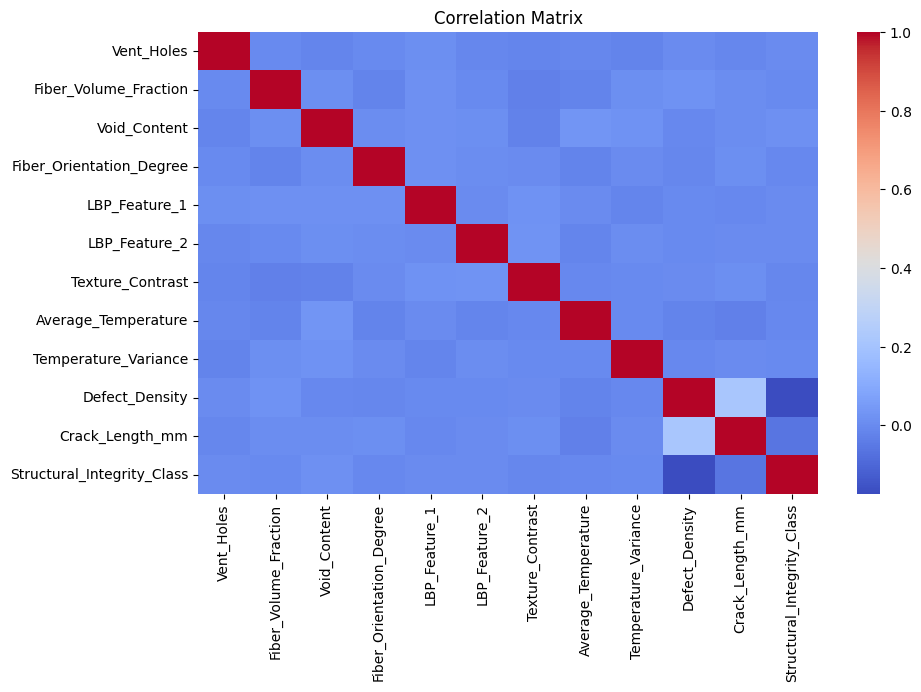

Final feature shape: (4080, 17)

===== BASELINE (Logistic Regression) =====
Baseline Accuracy: 0.6997549019607843

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       203
           1       0.71      0.98      0.83       572
           2       0.36      0.29      0.32        41

    accuracy                           0.70       816
   macro avg       0.36      0.42      0.38       816
weighted avg       0.52      0.70      0.59       816

Confusion Matrix:
 [[  0 195   8]
 [  0 559  13]
 [  0  29  12]]

===== TRAINING DEEP MODEL =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 0 Loss 40.8237
Epoch 1 Loss 35.2417
Epoch 2 Loss 34.5186
Epoch 3 Loss 33.7665
Epoch 4 Loss 33.5889
Epoch 5 Loss 33.5467
Epoch 6 Loss 33.3465
Epoch 7 Loss 33.0741
Epoch 8 Loss 32.9965
Epoch 9 Loss 32.7972
Epoch 10 Loss 32.5752
Epoch 11 Loss 32.4781
Epoch 12 Loss 32.7084
Epoch 13 Loss 32.4001
Epoch 14 Loss 32.4348

===== DEEP MODEL RESULTS =====
Deep Model Accuracy: 0.7009803921568627

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       203
           1       0.72      0.97      0.83       572
           2       0.38      0.49      0.43        41

    accuracy                           0.70       816
   macro avg       0.37      0.48      0.42       816
weighted avg       0.53      0.70      0.60       816

Confusion Matrix:
 [[  0 191  12]
 [  0 552  20]
 [  0  21  20]]

===== FINAL COMPARISON =====
Baseline Accuracy: 0.6997549019607843
Deep Model Accuracy: 0.7009803921568627


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# =========================
# IMPORTS
# =========================
import os, numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
df = pd.read_csv(CSV_PATH)

# =========================
# BASIC EDA
# =========================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

# =========================
# TARGET CLEANING
# =========================
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].astype(str).str.strip()
mapping = {'Low':0, 'Medium':1, 'High':2}
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].map(mapping)

df = df.dropna().reset_index(drop=True)

print("\nClass distribution:\n", df['Structural_Integrity_Class'].value_counts())

# =========================
# CORRELATION MATRIX
# =========================
num_cols = [
 'Vent_Holes','Fiber_Volume_Fraction','Void_Content','Fiber_Orientation_Degree',
 'LBP_Feature_1','LBP_Feature_2','Texture_Contrast',
 'Average_Temperature','Temperature_Variance','Defect_Density','Crack_Length_mm'
]

corr = df[num_cols + ['Structural_Integrity_Class']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================
# FEATURES
# =========================
cat_cols = ['Data_Type','Condition','Damage_Type']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

X = np.hstack([X_num, cat_encoded])
y = df['Structural_Integrity_Class'].values

print("Final feature shape:", X.shape)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# BASELINE MODEL
# =========================
print("\n===== BASELINE (Logistic Regression) =====")

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_base))

# =========================
# DATASET CLASS
# =========================
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train, y_train)
test_ds  = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

# =========================
# DEEP NEURAL NETWORK MODEL
# =========================
class TabularNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64,3)
        )

    def forward(self, x):
        return self.net(x)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = TabularNN(X.shape[1]).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# =========================
# TRAINING
# =========================
print("\n===== TRAINING DEEP MODEL =====")

for epoch in range(15):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        out = model(xb)
        loss = loss_fn(out, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")

# =========================
# EVALUATION (DEEP MODEL)
# =========================
model.eval()

preds, trues = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        out = model(xb)
        preds.extend(torch.argmax(out,1).cpu().numpy())
        trues.extend(yb.numpy())

print("\n===== DEEP MODEL RESULTS =====")
print("Deep Model Accuracy:", accuracy_score(trues, preds))

print("\nClassification Report:\n", classification_report(trues, preds))
print("Confusion Matrix:\n", confusion_matrix(trues, preds))

# =========================
# COMPARISON
# =========================
print("\n===== FINAL COMPARISON =====")
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Deep Model Accuracy:", accuracy_score(trues, preds))

Shape: (8080, 18)

Missing:
 Sample_ID                        0
Data_Type                        0
Condition                        0
Damage_Type                   4000
Vent_Holes                       0
Fiber_Volume_Fraction            0
Void_Content                     0
Fiber_Orientation_Degree         0
LBP_Feature_1                    0
LBP_Feature_2                    0
Texture_Contrast                 0
Average_Temperature              0
Temperature_Variance             0
Defect_Density                   0
Crack_Length_mm                  0
Fracture_Toughness               0
Tensile_Strength                 0
Structural_Integrity_Class       0
dtype: int64

Class distribution:
 Structural_Integrity_Class
1    2858
0    1016
2     206
Name: count, dtype: int64


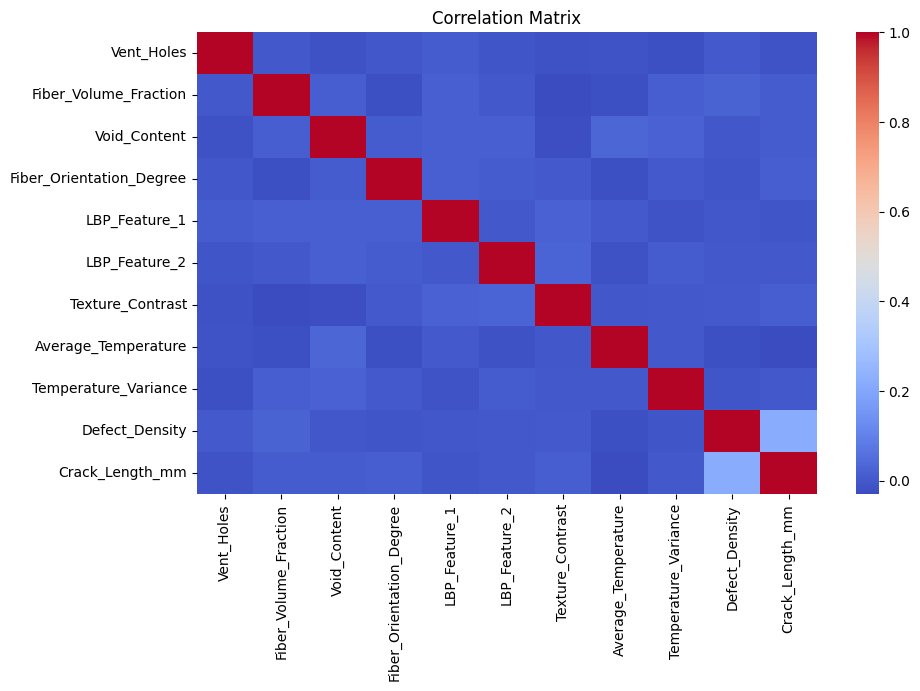


After SMOTE:
 1    2286
0    2286
2    2286
Name: count, dtype: int64
Epoch 0 Loss 90.9951
Epoch 1 Loss 76.7261
Epoch 2 Loss 72.4322
Epoch 3 Loss 71.0867
Epoch 4 Loss 70.0298
Epoch 5 Loss 67.4311
Epoch 6 Loss 66.1013
Epoch 7 Loss 66.9185
Epoch 8 Loss 65.1285
Epoch 9 Loss 63.9267
Epoch 10 Loss 63.9747
Epoch 11 Loss 62.5152
Epoch 12 Loss 62.1202
Epoch 13 Loss 62.0947
Epoch 14 Loss 61.2157
Epoch 15 Loss 60.6765
Epoch 16 Loss 60.8875
Epoch 17 Loss 59.4518
Epoch 18 Loss 60.3693
Epoch 19 Loss 59.5614

===== DEEP MODEL =====
Accuracy: 0.5294117647058824

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.39      0.31       203
           1       0.74      0.57      0.64       572
           2       0.38      0.68      0.49        41

    accuracy                           0.53       816
   macro avg       0.46      0.55      0.48       816
weighted avg       0.60      0.53      0.55       816



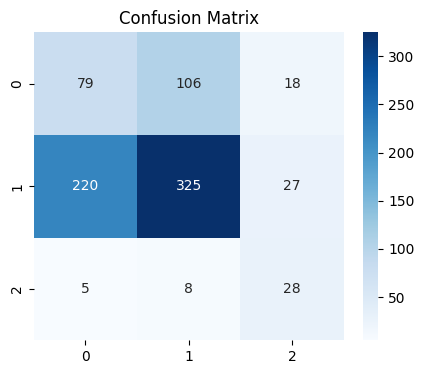

ROC-AUC: 0.6854564922943139
RMSE: 0.7450819141702001

===== BASELINE =====
Accuracy: 0.5049019607843137

Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.33      0.27       203
           1       0.73      0.53      0.62       572
           2       0.37      1.00      0.54        41

    accuracy                           0.50       816
   macro avg       0.44      0.62      0.47       816
weighted avg       0.59      0.50      0.53       816


===== FINAL COMPARISON =====
Baseline Accuracy: 0.5049019607843137
Deep Model Accuracy: 0.5294117647058824


In [20]:
# =========================
# IMPORTS
# =========================
import os, numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
df = pd.read_csv(CSV_PATH)

# =========================
# EDA
# =========================
print("Shape:", df.shape)
print("\nMissing:\n", df.isnull().sum())

df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].astype(str).str.strip()
mapping = {'Low':0, 'Medium':1, 'High':2}
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].map(mapping)

df = df.dropna().reset_index(drop=True)

print("\nClass distribution:\n", df['Structural_Integrity_Class'].value_counts())

# =========================
# CORRELATION
# =========================
num_cols = [
 'Vent_Holes','Fiber_Volume_Fraction','Void_Content','Fiber_Orientation_Degree',
 'LBP_Feature_1','LBP_Feature_2','Texture_Contrast',
 'Average_Temperature','Temperature_Variance','Defect_Density','Crack_Length_mm'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================
# FEATURES
# =========================
cat_cols = ['Data_Type','Condition','Damage_Type']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

X = np.hstack([X_num, cat_encoded])
y = df['Structural_Integrity_Class'].values

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# SMOTE BALANCING
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train).value_counts())

# =========================
# BASELINE
# =========================
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# =========================
# CLASS WEIGHTS
# =========================
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = torch.tensor(weights).float()

# =========================
# DATASET
# =========================
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train, y_train)
test_ds  = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

# =========================
# MODEL
# =========================
class TabularNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64,3)
        )

    def forward(self, x):
        return self.net(x)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = TabularNN(X.shape[1]).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

# =========================
# TRAIN
# =========================
for epoch in range(20):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        out = model(xb)
        loss = loss_fn(out, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")

# =========================
# EVALUATION
# =========================
model.eval()

preds, trues, probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb)

        prob = torch.softmax(out, dim=1)

        preds.extend(torch.argmax(out,1).cpu().numpy())
        probs.extend(prob.cpu().numpy())
        trues.extend(yb.numpy())

# =========================
# METRICS
# =========================
print("\n===== DEEP MODEL =====")
print("Accuracy:", accuracy_score(trues, preds))
print("\nClassification Report:\n", classification_report(trues, preds))

# Confusion Matrix
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC
try:
    roc = roc_auc_score(trues, probs, multi_class='ovr')
    print("ROC-AUC:", roc)
except:
    print("ROC-AUC not computable")

# RMSE (classification numeric error)
rmse = np.sqrt(mean_squared_error(trues, preds))
print("RMSE:", rmse)

# =========================
# BASELINE COMPARISON
# =========================
print("\n===== BASELINE =====")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base))

# =========================
# FINAL COMPARISON
# =========================
print("\n===== FINAL COMPARISON =====")
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Deep Model Accuracy:", accuracy_score(trues, preds))

Shape: (8080, 18)

Missing:
 Sample_ID                        0
Data_Type                        0
Condition                        0
Damage_Type                   4000
Vent_Holes                       0
Fiber_Volume_Fraction            0
Void_Content                     0
Fiber_Orientation_Degree         0
LBP_Feature_1                    0
LBP_Feature_2                    0
Texture_Contrast                 0
Average_Temperature              0
Temperature_Variance             0
Defect_Density                   0
Crack_Length_mm                  0
Fracture_Toughness               0
Tensile_Strength                 0
Structural_Integrity_Class       0
dtype: int64

Class distribution:
 Structural_Integrity_Class
1    2858
0    1016
2     206
Name: count, dtype: int64


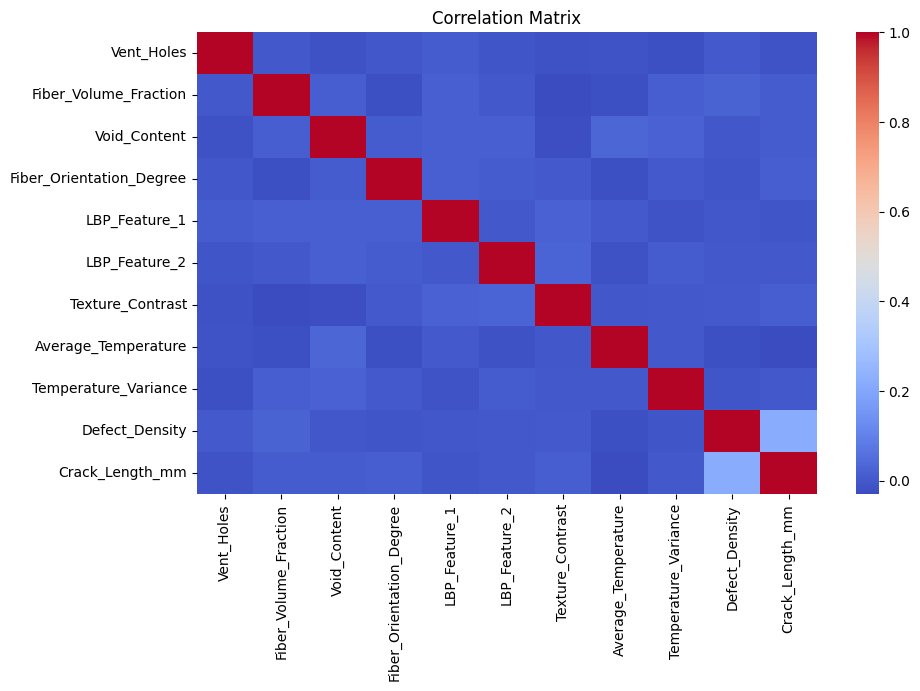


After SMOTE:
 1    2286
0    2286
2    2286
Name: count, dtype: int64
Epoch 0 Loss 90.8509
Epoch 1 Loss 76.6907
Epoch 2 Loss 73.7766
Epoch 3 Loss 71.9612
Epoch 4 Loss 69.7091
Epoch 5 Loss 69.0397
Epoch 6 Loss 67.4953
Epoch 7 Loss 66.4519
Epoch 8 Loss 65.6404
Epoch 9 Loss 63.9330
Epoch 10 Loss 64.1009
Epoch 11 Loss 63.7554
Epoch 12 Loss 61.8481
Epoch 13 Loss 61.1950
Epoch 14 Loss 61.3058
Epoch 15 Loss 60.8417
Epoch 16 Loss 60.3618
Epoch 17 Loss 60.4970
Epoch 18 Loss 58.6631
Epoch 19 Loss 59.7270

===== DEEP MODEL =====
Accuracy: 0.5404411764705882

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.35      0.30       203
           1       0.75      0.59      0.66       572
           2       0.38      0.85      0.53        41

    accuracy                           0.54       816
   macro avg       0.46      0.60      0.49       816
weighted avg       0.61      0.54      0.56       816



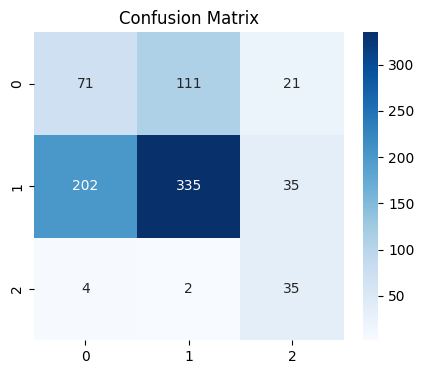

ROC-AUC: 0.6958228236597076
RMSE: 0.7426106572325057

===== BASELINE =====
Accuracy: 0.5049019607843137

Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.33      0.27       203
           1       0.73      0.53      0.62       572
           2       0.37      1.00      0.54        41

    accuracy                           0.50       816
   macro avg       0.44      0.62      0.47       816
weighted avg       0.59      0.50      0.53       816


===== FINAL COMPARISON =====
Baseline Accuracy: 0.5049019607843137
Deep Model Accuracy: 0.5404411764705882


In [26]:
# =========================
# IMPORTS
# =========================
import os, numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
CSV_PATH = "/content/drive/MyDrive/archive (8)/CFRP_dataset.csv"
df = pd.read_csv(CSV_PATH)

# =========================
# EDA
# =========================
print("Shape:", df.shape)
print("\nMissing:\n", df.isnull().sum())

df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].astype(str).str.strip()
mapping = {'Low':0, 'Medium':1, 'High':2}
df['Structural_Integrity_Class'] = df['Structural_Integrity_Class'].map(mapping)

df = df.dropna().reset_index(drop=True)

print("\nClass distribution:\n", df['Structural_Integrity_Class'].value_counts())

# =========================
# CORRELATION
# =========================
num_cols = [
 'Vent_Holes','Fiber_Volume_Fraction','Void_Content','Fiber_Orientation_Degree',
 'LBP_Feature_1','LBP_Feature_2','Texture_Contrast',
 'Average_Temperature','Temperature_Variance','Defect_Density','Crack_Length_mm'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================
# FEATURES
# =========================
cat_cols = ['Data_Type','Condition','Damage_Type']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

X = np.hstack([X_num, cat_encoded])
y = df['Structural_Integrity_Class'].values

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# SMOTE BALANCING
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train).value_counts())

# =========================
# BASELINE
# =========================
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# =========================
# CLASS WEIGHTS
# =========================
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = torch.tensor(weights).float()

# =========================
# DATASET
# =========================
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train, y_train)
test_ds  = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

# =========================
# MODEL
# =========================
class TabularNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64,3)
        )

    def forward(self, x):
        return self.net(x)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = TabularNN(X.shape[1]).to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

# =========================
# TRAIN
# =========================
for epoch in range(20):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        out = model(xb)
        loss = loss_fn(out, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")

# =========================
# EVALUATION
# =========================
model.eval()

preds, trues, probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb)

        prob = torch.softmax(out, dim=1)

        preds.extend(torch.argmax(out,1).cpu().numpy())
        probs.extend(prob.cpu().numpy())
        trues.extend(yb.numpy())

# =========================
# METRICS
# =========================
print("\n===== DEEP MODEL =====")
print("Accuracy:", accuracy_score(trues, preds))
print("\nClassification Report:\n", classification_report(trues, preds))

# Confusion Matrix
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC
try:
    roc = roc_auc_score(trues, probs, multi_class='ovr')
    print("ROC-AUC:", roc)
except:
    print("ROC-AUC not computable")

# RMSE (classification numeric error)
rmse = np.sqrt(mean_squared_error(trues, preds))
print("RMSE:", rmse)

# =========================
# BASELINE COMPARISON
# =========================
print("\n===== BASELINE =====")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base))

# =========================
# FINAL COMPARISON
# =========================
print("\n===== FINAL COMPARISON =====")
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Deep Model Accuracy:", accuracy_score(trues, preds))